# Poisson-Harmonic Demand Model

Fits the model derived in `docs/poisson_harmonic_demand_model.tex`: a GLM (log
link) for total trip counts $Y_{z,t}$ by taxi zone $z$ and hourly bucket $t$,
with zone fixed effects, harmonic (Fourier) seasonality terms, weather, an
event-proximity feature, and per-zone lagged demand. Several GLM variants
(event-feature forms; Poisson vs negative binomial) are compared on a held-out
December, then a gradient-boosted tree model is fit on the same features as a
nonparametric benchmark.

**Data source**: `data/processed/demand/` (parquet), written by
`scripts/generate_design_matrix.py` (a full-year PySpark job over the raw trip
files). That output is the *feature table* at (zone, hour) grain; the GLM
design matrix (harmonics, zone dummies, splits) is assembled here in pandas.

**Implementation note — no formula API.** The design matrix is built manually
(`pd.get_dummies` + `sm.GLM(y, X)`) rather than via `smf.glm("y ~ ...")`.
On this environment (Python 3.14 / pandas 3.0) the patsy formula path is
broken: identical models that fit in seconds from explicit matrices either
crash IRLS with `NaN, inf or invalid value detected in weights` or hang with
runaway memory when routed through patsy. Everything below is patsy-free.

In [1]:
import gc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingRegressor

DATA_DIR = "../data"
PLOTS_DIR = "../plots"
YEAR = 2025
SEED = 42

## 1. Load the feature table

`generate_design_matrix.py` writes a parquet directory; `read_parquet` on the
directory picks up all part-files.

In [2]:
demand = pd.read_parquet(f"{DATA_DIR}/processed/demand")
print(demand.shape)
demand.head()

(2303880, 30)


,pickup_hour,LocationID,taxi_trip_count,taxi_avg_distance,taxi_var_distance,taxi_avg_duration,taxi_var_duration,taxi_avg_cost,taxi_avg_tip,taxi_total_tip,...,precip_mm,weather_type,total_trip_count,taxi_count_lag2,taxi_count_lag24,taxi_count_lag168,taxi_avg_distance_lag2,taxi_avg_duration_lag2,taxi_avg_cost_lag2,taxi_avg_tip_lag2
0,2025-01-01 00:00:00,18,1,7.47,0.0000,19.816667,0.00000,13.95,0.0,0.0,...,0.0,NaN,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 01:00:00,18,0,NaN,0.0000,NaN,0.00000,NaN,NaN,0.0,...,0.0,NaN,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 02:00:00,18,0,NaN,0.0000,NaN,0.00000,NaN,NaN,0.0,...,0.0,NaN,291,1.0,NaN,NaN,7.47,19.816667,13.95,0.0
3,2025-01-01 03:00:00,18,2,4.93,0.1058,16.425000,5.61125,12.58,0.0,0.0,...,0.0,NaN,227,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 04:00:00,18,0,NaN,0.0000,NaN,0.00000,NaN,NaN,0.0,...,0.0,NaN,175,0.0,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Event-proximity feature: check the distribution first

Before deciding indicator (`event_count > 0`) vs raw count vs a capped count,
look at how much real variation there is. If it's almost entirely 0/1 with a
handful of 2s, a raw count is being estimated off very little data and a
binary/capped feature is the safer choice (see discussion in project notes).

event_count
0    2198741
1      82568
2      14990
3       6113
4       1054
5        207
6        138
7         69
Name: count, dtype: int64


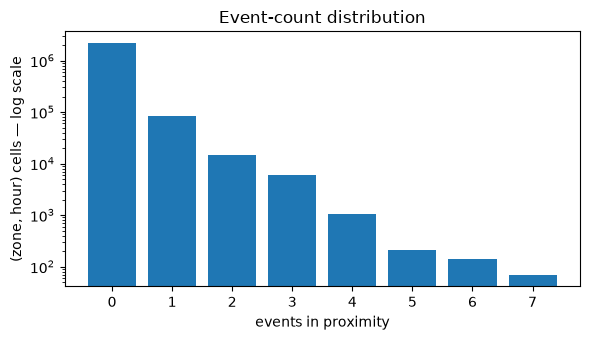

In [3]:
counts = demand["event_count"].value_counts().sort_index()
print(counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(counts.index, counts.values)
ax.set_yscale("log")
ax.set_xlabel("events in proximity")
ax.set_ylabel("(zone, hour) cells — log scale")
ax.set_title("Event-count distribution")
plt.tight_layout()
plt.show()

# ~95% zeros with a geometric-looking tail to 7: enough 2s/3s that intensity
# *might* matter beyond mere presence, but too few 4+ to estimate a raw linear
# count reliably. Three candidate encodings are compared in the model section:
# binary is_event, log1p(event_count), and a capped categorical (0/1/2/3+).

## 3. Harmonic (Fourier) seasonality terms

Per `.tex` §4: for each period $P$ (daily=24h, weekly=168h, annual≈8766h) and
harmonic $k=1..K$, add $\cos(2\pi k t/P)$ and $\sin(2\pi k t/P)$, where $t$ is
*continuous* elapsed hours from a **fixed** origin -- not `pickup_hour.min()`.
Anchoring to the data's own min would give train and test different phase
references for the same calendar hour once we split below, which would quietly
break the model. `K` values here are starting points (daily=2 for the AM/PM
commute bimodality, weekly/annual=1) -- confirm with a periodogram on the
aggregate series and bump only if a higher harmonic clearly earns its keep
(LR test / AIC, §4.4).

In [4]:
EPOCH = pd.Timestamp(f"{YEAR}-01-01 00:00:00")

HARMONIC_PERIODS = {
    "daily": (24, 2),
    "weekly": (24 * 7, 1),
    "annual": (24 * 365.25, 1),
}


def add_harmonics(df, time_col, periods):
    t = (df[time_col] - EPOCH) / pd.Timedelta(hours=1)
    for name, (P, K) in periods.items():
        for k in range(1, K + 1):
            df[f"{name}_cos{k}"] = np.cos(2 * np.pi * k * t / P)
            df[f"{name}_sin{k}"] = np.sin(2 * np.pi * k * t / P)
    return df


demand = add_harmonics(demand, "pickup_hour", HARMONIC_PERIODS)
harmonic_cols = [c for c in demand.columns if c.split("_")[0] in HARMONIC_PERIODS]
demand[["pickup_hour"] + harmonic_cols].head()

,pickup_hour,daily_cos1,daily_sin1,daily_cos2,daily_sin2,weekly_cos1,weekly_sin1,annual_cos1,annual_sin1
0,2025-01-01 00:00:00,1.000000,0.000000,1.000000e+00,0.000000,1.000000,0.000000,1.000000,0.000000
1,2025-01-01 01:00:00,0.965926,0.258819,8.660254e-01,0.500000,0.999301,0.037391,1.000000,0.000717
2,2025-01-01 02:00:00,0.866025,0.500000,5.000000e-01,0.866025,0.997204,0.074730,0.999999,0.001434
3,2025-01-01 03:00:00,0.707107,0.707107,6.123234e-17,1.000000,0.993712,0.111964,0.999998,0.002150
4,2025-01-01 04:00:00,0.500000,0.866025,-5.000000e-01,0.866025,0.988831,0.149042,0.999996,0.002867


## 4. Cleaning & feature engineering

Diagnostics on the raw feature table found four data problems, each handled
below (one cell, idempotent — safe to re-run):

1. **`weather_type` is raw METAR present-weather strings** (~60 near-unique
   levels like `"+RA:02 SN:03 BR:1 |RA SN BR |RA"`, many backed by <5 rows).
   One-hot encoding that is unstable (near-perfectly-fit dummies); a coarse
   recode to 5 categories costs almost no fit (deviance 286.3k vs 284.4k on a
   2% probe) for 56 fewer columns.
2. **Data-error outliers in the lag-2 trip aggregates**: max
   `taxi_avg_distance_lag2` = 234,140 miles, min `taxi_avg_duration_lag2` =
   −4,276 min. Under a log link a 2×10⁵-valued covariate overflows `exp()`.
   Clipped here; since fixed upstream (`generate_design_matrix.py` now nulls
   impossible metric values before aggregating), so the clip is an inert guard.
3. **NaN patterns that silently shrink the sample**: the `taxi_avg_*_lag2`
   aggregates are NaN on 38% of rows (zero-taxi hours) and `precip_mm` on 32%
   (no reading). Dropping those rows would bias the sample toward busy hours,
   so instead: precip NaN → 0, aggregate NaNs → 0 plus an explicit
   `no_taxi_lag2` indicator so the model can tell "no trips" from "cheap trips".
4. **Zones with an all-zero response in training** (e.g. zone 2, Jamaica Bay)
   have no finite fixed-effect MLE (the Poisson analogue of perfect
   separation); they're excluded at split time below.

Also adds: per-zone lags of the **response** (`total_count_lag{2,24,168}`,
computable because the grid is complete — 263 zones × 8,760 hours exactly),
`log1p` versions of all count-scale features for the log-link GLM (raw
versions are kept for the tree model, which prefers them untransformed), the
three candidate event encodings, and calendar fields for the tree model.

In [5]:
# --- build the modelling frame (idempotent: rebuilt from `demand` each run) ---
usable = demand[~demand["total_trip_count"].isna()].copy()
del demand  # never referenced again; the wide raw table (~700MB) shouldn't
gc.collect()  # linger for the rest of the notebook run

usable = usable.sort_values(["LocationID", "pickup_hour"]).reset_index(drop=True)

# per-zone lags of the response. Row-shift == hour-shift only because the grid
# is complete (every zone has every hour); lag before ANY row filtering.
# Min lag of 2 matches the availability assumption of the Spark-built lags.
for L in (2, 24, 168):
    usable[f"total_count_lag{L}"] = (
        usable.groupby("LocationID")["total_trip_count"].shift(L)
    )

# -- weather --
# NaN present-weather string = "nothing to report"
usable["weather_type"] = usable["weather_type"].fillna("none")


def simplify_weather(w):
    if w == "none":
        return "none"
    if "TS" in w:
        return "thunderstorm"
    if "SN" in w or "PL" in w or "FZ" in w or "GS" in w:
        return "snow_ice"
    if "RA" in w or "DZ" in w:
        return "rain"
    return "fog_haze_other"  # BR/FG/HZ/FU and anything unrecognised


usable["weather_cat"] = usable["weather_type"].map(simplify_weather)
# precip NaN = no reading at the station; treat as no precipitation
usable["precip_mm"] = usable["precip_mm"].fillna(0.0)

# -- lag-2 trip-characteristic aggregates --
# indicator BEFORE filling: NaN here means "no taxi trips 2h ago in this zone"
usable["no_taxi_lag2"] = usable["taxi_avg_distance_lag2"].isna().astype(float)
# clip data-error outliers (234k-mile distances, negative durations), then
# 0-fill the no-trip NaNs (the indicator carries that information)
usable["taxi_avg_distance_lag2"] = usable["taxi_avg_distance_lag2"].clip(0, 100).fillna(0.0)
usable["taxi_avg_duration_lag2"] = usable["taxi_avg_duration_lag2"].clip(0, 300).fillna(0.0)
usable["taxi_avg_cost_lag2"] = usable["taxi_avg_cost_lag2"].clip(-50, 500).fillna(0.0)
usable["taxi_avg_tip_lag2"] = usable["taxi_avg_tip_lag2"].clip(0, 200).fillna(0.0)

# -- event encodings (three candidate forms, compared in §6) --
usable["is_event"] = (usable["event_count"] > 0).astype(float)
usable["log1p_event_count"] = np.log1p(usable["event_count"])
usable["event_cat"] = usable["event_count"].clip(upper=3).astype(int)  # 0,1,2,3+

# -- count-scale features -> log1p for the log-link GLM --
# (raw versions stay on the frame for the tree model)
COUNT_LAG_COLS = [
    "taxi_count_lag2", "taxi_count_lag24", "taxi_count_lag168",
    "total_count_lag2", "total_count_lag24", "total_count_lag168",
]
for c in COUNT_LAG_COLS:
    usable[f"log1p_{c}"] = np.log1p(usable[c])

# -- calendar fields for the tree model (the GLM uses harmonics instead) --
usable["hour"] = usable["pickup_hour"].dt.hour
usable["dow"] = usable["pickup_hour"].dt.dayofweek
usable["month"] = usable["pickup_hour"].dt.month

print(f"{len(usable):,} rows, {usable['LocationID'].nunique()} zones")
print(usable["weather_cat"].value_counts().to_string())

2,303,880 rows, 263 zones
weather_cat
none              2013791
rain               184363
fog_haze_other      64172
snow_ice            32086
thunderstorm         9468


In [6]:
RESPONSE = "total_trip_count"

# numeric features shared by every GLM variant
FEATURES_COUNT_LAGS = [f"log1p_{c}" for c in COUNT_LAG_COLS]
FEATURES_TRIPCHAR = [
    "taxi_avg_distance_lag2", "taxi_avg_duration_lag2",
    "taxi_avg_cost_lag2", "taxi_avg_tip_lag2", "no_taxi_lag2",
]
FEATURES_SEASONAL = harmonic_cols
FEATURES_WEATHER = ["temp_c", "precip_mm"]
NUM_BASE = FEATURES_COUNT_LAGS + FEATURES_TRIPCHAR + FEATURES_SEASONAL + FEATURES_WEATHER

# columns whose NaN we deliberately did NOT impute (lag warm-up, missing temp):
# rows missing these are dropped from the GLM sets
GLM_REQUIRED = FEATURES_COUNT_LAGS + ["temp_c"]


def build_cat_block(df, cat_specs):
    """Dummy-code each categorical against fixed levels (first level =
    baseline, dropped). Fixed levels keep train/test columns aligned;
    unseen test levels fall to the baseline."""
    blocks = []
    for col, levels in cat_specs.items():
        cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])
        # int8, not float64: these are 0/1 indicators. At ~260 zone levels
        # this is an 8x cut to the dominant chunk of every design matrix's
        # memory (sm.GLM casts to float64 internally via .to_numpy(float)
        # at fit time, so this costs nothing at estimation).
        dummies = pd.get_dummies(cat, prefix=col, dtype=np.int8).iloc[:, 1:]
        dummies.index = df.index
        blocks.append(dummies)
    return blocks


def build_shared_design(df, cat_specs):
    """Intercept + dummy blocks for categoricals common to every GLM variant
    (zone, weather). One-hot-encoding 261 zone levels is the expensive part
    of build_design, and every variant plus the NB/cluster-robust refits
    used the identical encoding — built once here and reused (previously
    rebuilt 5x, which is what was driving WSL OOM)."""
    blocks = [pd.DataFrame({"const": np.ones(len(df))}, index=df.index)]
    blocks += build_cat_block(df, cat_specs)
    return pd.concat(blocks, axis=1)


def build_design(df, num_cols, cat_specs, shared=None):
    """Design matrix: numeric cols as-is plus dummy-coded categoricals.
    Pass `shared` (a build_shared_design result for this same df) to reuse
    an already-built zone/weather block instead of re-encoding it — then
    `cat_specs` should hold only the variant-specific extra categoricals."""
    if shared is not None:
        blocks = [shared, df[num_cols].astype(float)]
    else:
        blocks = [
            pd.DataFrame({"const": np.ones(len(df))}, index=df.index),
            df[num_cols].astype(float),
        ]
    blocks += build_cat_block(df, cat_specs)
    return pd.concat(blocks, axis=1)


def poisson_deviance(y, mu):
    """Mean Poisson deviance — valid as a predictive score for any model
    that outputs a conditional mean (GLM, NB, trees, naive baseline)."""
    y = np.asarray(y, float)
    mu = np.maximum(np.asarray(mu, float), 1e-9)
    # y log(y/mu) with the y=0 limit (0) taken explicitly: the log is only
    # evaluated where y > 0, so no log(0) warnings from np.where's eager branches
    term = np.zeros_like(y)
    pos = y > 0
    term[pos] = y[pos] * np.log(y[pos] / mu[pos])
    return 2.0 * float(np.mean(term - (y - mu)))


def score(y, mu):
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    return {
        "test_MAE": float(np.mean(np.abs(y - mu))),
        "test_RMSE": float(np.sqrt(np.mean((y - mu) ** 2))),
        "test_poisson_dev": poisson_deviance(y, mu),
    }

In [7]:
# --- time-based split: train Jan-Nov, test December ---
# (matches the deployment question; a random row split would let the model
# see both neighbours of an hour it's meant to be forecasting)
SPLIT_DATE = pd.Timestamp(f"{YEAR}-12-01")

train_full = usable[usable["pickup_hour"] < SPLIT_DATE]   # tree model uses all of this
test_full = usable[usable["pickup_hour"] >= SPLIT_DATE]

# GLM: a 5% row sample keeps the dense (n x ~290) design matrix comfortably
# in memory; fits stabilised well below this size in earlier probes. (Was
# 10% — the NB/binomial GLM fits' internal IRLS working memory, not the
# design matrix itself, was the dominant memory cost at that n; 5% still
# leaves ~400 rows/zone, ample per the .tex's own sampling-bias argument.)
GLM_FRAC = 0.05
glm_train = (
    train_full.sample(frac=GLM_FRAC, random_state=SEED)
    .dropna(subset=GLM_REQUIRED)
)

# zones with an all-zero response in training have no finite fixed-effect MLE
zone_sum = glm_train.groupby("LocationID")[RESPONSE].sum()
GOOD_ZONES = zone_sum[zone_sum > 0].index
dropped = sorted(set(glm_train["LocationID"].unique()) - set(GOOD_ZONES))
glm_train = glm_train[glm_train["LocationID"].isin(GOOD_ZONES)]

# common evaluation set for ALL models (GLM can only score zones it estimated)
glm_test = test_full.dropna(subset=GLM_REQUIRED)
glm_test = glm_test[glm_test["LocationID"].isin(GOOD_ZONES)]
del test_full  # superseded by glm_test; train_full stays (the GBM cell needs it)
gc.collect()

print(f"GLM train: {len(glm_train):,} rows "
      f"({glm_train['pickup_hour'].min():%Y-%m-%d} .. {glm_train['pickup_hour'].max():%Y-%m-%d})")
print(f"test:      {len(glm_test):,} rows "
      f"({glm_test['pickup_hour'].min():%Y-%m-%d} .. {glm_test['pickup_hour'].max():%Y-%m-%d})")
print(f"zones kept: {len(GOOD_ZONES)} | dropped (all-zero in train): {dropped}")

GLM train: 100,887 rows (2025-01-08 .. 2025-11-30)
test:      194,184 rows (2025-12-01 .. 2025-12-31)
zones kept: 261 | dropped (all-zero in train): [np.int32(103), np.int32(104)]


## 5. Fit & compare Poisson GLM variants

All variants share the same base: zone fixed effects, harmonics, weather
(coarse categories + temp/precip), lagged per-zone demand (taxi and total,
log1p), and the lag-2 trip-characteristic aggregates. They differ only in the
**event-proximity encoding**:

- `event_binary` — presence only (`is_event`)
- `event_log1p` — diminishing-returns intensity (`log1p(event_count)`)
- `event_cat` — free shape via capped categorical (0 / 1 / 2 / 3+)

The contemporaneous same-hour aggregates (`taxi_avg_distance`, `rideshare_*`,
...) stay excluded: they're computed from the same cell's own trips, so using
them to predict that cell's count would be circular. Only **lagged** trip
characteristics enter.

Selection is by held-out December performance (mean Poisson deviance, with
MAE/RMSE alongside); train-side AIC is reported for reference. The `event_cat`
coefficient pattern also tells us the effect's shape directly: roughly
evenly-spaced steps → linear; flattening → log-like; equal steps → binary.

In [8]:
# --- fitted-model cache ---
# Each slow fit below is pickled to ../models the first time it runs and
# loaded from disk on every rerun. The cache CANNOT detect changes to the
# data, features, split, SEED or GLM_FRAC — after changing any of those,
# delete the stale file(s) (or the whole ../models folder) to force a refit.
import os
import joblib

MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

# statistics preserved through remove_data() — see save_glm below
GLM_KEEP_STATS = (
    "llf", "llnull", "aic", "bic_llf", "bic_deviance",
    "deviance", "null_deviance", "pearson_chi2",
    "df_resid", "df_model", "bse", "pvalues",
)


def save_glm(res, path):
    """Pickle a statsmodels results object without its training arrays
    (which would otherwise embed the full n x ~290 design matrix).
    On this statsmodels version (0.14.6) remove_data() wipes EVERY cached
    attribute to None — scalars included — so touching them first is not
    enough: the values are computed up front and written back into the
    results cache after the wipe, which round-trips through the pickle."""
    r = res._results  # unwrap: the cache stores unwrapped values
    kept = {a: getattr(r, a) for a in GLM_KEEP_STATS}
    res.remove_data()
    r._cache.update(kept)
    res.save(path)


def fit_or_load(path, fit_fn):
    if os.path.exists(path):
        print(f"  (loaded cached {path})")
        return sm.load(path)
    res = fit_fn()
    save_glm(res, path)
    return res

In [9]:
WEATHER_LEVELS = ["none", "rain", "snow_ice", "thunderstorm", "fog_haze_other"]
CAT_BASE = {
    "LocationID": sorted(GOOD_ZONES),          # baseline = lowest zone id
    "weather_cat": [w for w in WEATHER_LEVELS  # baseline = "none"
                    if w in set(glm_train["weather_cat"])],
}

VARIANTS = {
    "event_binary": (NUM_BASE + ["is_event"], CAT_BASE),
    "event_log1p": (NUM_BASE + ["log1p_event_count"], CAT_BASE),
    "event_cat": (NUM_BASE, {**CAT_BASE, "event_cat": [0, 1, 2, 3]}),
}

# zone/weather dummy block is identical across all 3 variants -> built once
# per split and reused (see build_shared_design)
SHARED_TRAIN = build_shared_design(glm_train, CAT_BASE)
SHARED_TEST = build_shared_design(glm_test, CAT_BASE)

y_train = glm_train[RESPONSE].to_numpy(float)
y_test = glm_test[RESPONSE].to_numpy(float)

fits = {}       # name -> fitted results object
mus = {}        # name -> predicted test means
metrics = {}    # name -> score dict
Xs_train = {}   # name -> train design matrix (kept: reused by S6's NB refit
Xs_test = {}    # and the IRR-shape check below instead of rebuilding them)

for name, (num_cols, cat_specs) in VARIANTS.items():
    extra_cats = {k: v for k, v in cat_specs.items() if k not in CAT_BASE}
    X_tr = build_design(glm_train, num_cols, extra_cats, shared=SHARED_TRAIN)
    X_te = build_design(glm_test, num_cols, extra_cats, shared=SHARED_TEST)
    Xs_train[name], Xs_test[name] = X_tr, X_te
    res = fit_or_load(
        f"{MODELS_DIR}/poisson_{name}.pkl",
        lambda: sm.GLM(y_train, X_tr.to_numpy(float),
                       family=sm.families.Poisson()).fit(maxiter=100),
    )
    res.model.data.xnames = list(X_tr.columns)  # keep names for summaries
    mu = res.predict(X_te.to_numpy(float))
    fits[name], mus[name] = res, mu
    metrics[name] = {
        **score(y_test, mu),
        "train_AIC": res.aic,
        "converged": res.converged,
        "n_params": X_tr.shape[1],
    }
    print(f"{name:14s} fitted: {metrics[name]}")

# every X_tr/X_te above was built by pd.concat-ing SHARED_TRAIN/SHARED_TEST in
# (a copy, not a view), so the shared blocks are dead weight now — 3 variants'
# worth of a ~260-column zone/weather dummy block held simultaneously was the
# other big chunk of the WSL OOM alongside the float64 dummies in build_cat_block
del SHARED_TRAIN, SHARED_TEST
gc.collect()

# event-effect shape from the free-form variant (IRR vs the 0-event baseline)
ev_params = pd.Series(fits["event_cat"].params, index=Xs_train["event_cat"].columns)
print("\nevent_cat IRRs (vs 0 events):")
print(np.exp(ev_params.filter(like="event_cat_")).round(3).to_string())

pd.DataFrame(metrics).T.sort_values("test_poisson_dev")

event_binary   fitted: {'test_MAE': 24.008163828490133, 'test_RMSE': 50.934338745824164, 'test_poisson_dev': 9.283702173910703, 'train_AIC': np.float64(1099933.3166645935), 'converged': True, 'n_params': 287}


event_log1p    fitted: {'test_MAE': 24.011353714610127, 'test_RMSE': 50.93724172161341, 'test_poisson_dev': 9.284425744324306, 'train_AIC': np.float64(1099931.694213036), 'converged': True, 'n_params': 287}


event_cat      fitted: {'test_MAE': 24.009703032587026, 'test_RMSE': 50.93535209374116, 'test_poisson_dev': 9.283898534633154, 'train_AIC': np.float64(1099917.7089191237), 'converged': True, 'n_params': 289}



event_cat IRRs (vs 0 events):
event_cat_1    1.006
event_cat_2    1.021
event_cat_3    1.006


,test_MAE,test_RMSE,test_poisson_dev,train_AIC,converged,n_params
event_binary,24.008164,50.934339,9.283702,1099933.316665,True,287
event_cat,24.009703,50.935352,9.283899,1099917.708919,True,289
event_log1p,24.011354,50.937242,9.284426,1099931.694213,True,287


## 6. Overdispersion check → negative binomial

Poisson assumes $\text{Var}(Y_i) = \mathbb{E}[Y_i]$ (`.tex` §5). Dispersion
$\hat\phi = X^2/(n-p)$ well above 1 violates that, understating standard
errors. The cell below estimates $\hat\phi$ on the best Poisson variant, gets
a moment estimate of the NB dispersion $\alpha$ via the Cameron–Trivedi
auxiliary regression $[(y_i-\hat\mu_i)^2 - y_i]/\hat\mu_i = \alpha\,\hat\mu_i$,
and refits that variant as a negative binomial GLM.

Note: NB and Poisson share the same mean structure, so **point predictions
barely move** — the NB's value is honest variance/intervals and coefficient
inference, not better point forecasts. Selection between them therefore uses
the dispersion diagnostic, not test MAE.

In [10]:
# best Poisson variant by held-out deviance
BEST_VARIANT = min(VARIANTS, key=lambda k: metrics[k]["test_poisson_dev"])
best_num, best_cats = VARIANTS[BEST_VARIANT]
best_pois = fits[BEST_VARIANT]
print(f"best Poisson variant: {BEST_VARIANT}")

# reuse the matrix this variant was actually fit on (§5) instead of
# rebuilding the 261-zone dummy encoding a second time
X_tr_best = Xs_train[BEST_VARIANT]
X_te_best = Xs_test[BEST_VARIANT]
# Xs_train/Xs_test held all 3 variants' design matrices at once; only the
# winner is needed from here on, so drop the dicts (and the other 2 copies)
del Xs_train, Xs_test
gc.collect()

dispersion = best_pois.pearson_chi2 / best_pois.df_resid
print(f"Pearson chi2 / df_resid (dispersion): {dispersion:.2f}")

# Cameron-Trivedi auxiliary OLS (through the origin) for the NB alpha.
# Train-set mu is recomputed via predict: the pickled fits don't carry .mu.
mu_tr = best_pois.predict(X_tr_best.to_numpy(float))
aux_y = ((y_train - mu_tr) ** 2 - y_train) / mu_tr
alpha_hat = max(float(sm.OLS(aux_y, mu_tr).fit().params[0]), 1e-3)
print(f"estimated NB alpha: {alpha_hat:.4f}")

nb_res = fit_or_load(
    f"{MODELS_DIR}/negbin_{BEST_VARIANT}.pkl",
    lambda: sm.GLM(
        y_train, X_tr_best.to_numpy(float),
        family=sm.families.NegativeBinomial(alpha=alpha_hat),
    ).fit(maxiter=100),
)
nb_res.model.data.xnames = list(X_tr_best.columns)
nb_name = f"negbin_{BEST_VARIANT}"
mus[nb_name] = nb_res.predict(X_te_best.to_numpy(float))
metrics[nb_name] = {
    **score(y_test, mus[nb_name]),
    "train_AIC": nb_res.aic,
    "converged": nb_res.converged,
    "n_params": X_tr_best.shape[1],
}
fits[nb_name] = nb_res
del X_te_best  # not used again; X_tr_best stays (cluster-robust refit needs it)
gc.collect()

comparison = pd.DataFrame(metrics).T.sort_values("test_poisson_dev")
print(f"\ndispersion >> 1 -> the NB fit is the one to report inference from")
comparison

best Poisson variant: event_binary
Pearson chi2 / df_resid (dispersion): 5.98


estimated NB alpha: 0.0315



dispersion >> 1 -> the NB fit is the one to report inference from


,test_MAE,test_RMSE,test_poisson_dev,train_AIC,converged,n_params
negbin_event_binary,23.790977,50.631211,9.020996,830652.372321,True,287
event_binary,24.008164,50.934339,9.283702,1099933.316665,True,287
event_cat,24.009703,50.935352,9.283899,1099917.708919,True,289
event_log1p,24.011354,50.937242,9.284426,1099931.694213,True,287


## 7. Cluster-robust standard errors (by zone)

Counts from the same zone are dependent over time, which breaks the
independence assumption behind the model-based SEs (`.tex` §2.5). The GLM
training rows are a *random subsample*, not a contiguous series, so
Newey–West/HAC SEs (which assume an ordered, evenly-spaced series) don't
apply here; instead we cluster by `LocationID`, which is robust to arbitrary
dependence *within* each zone. Report p-values / CIs from this fit, not the
naive one.

In [11]:
groups = glm_train["LocationID"].to_numpy()
robust_res = fit_or_load(
    f"{MODELS_DIR}/negbin_{BEST_VARIANT}_cluster.pkl",
    lambda: sm.GLM(
        y_train, X_tr_best.to_numpy(float),
        family=sm.families.NegativeBinomial(alpha=alpha_hat),
    ).fit(maxiter=100, cov_type="cluster", cov_kwds={"groups": groups}),
)
robust_res.model.data.xnames = list(X_tr_best.columns)

# non-zone terms only (the ~260 zone dummies are rarely the interesting part)
param_names = pd.Index(X_tr_best.columns)
keep = ~param_names.str.startswith("LocationID_")
summary_tbl = pd.DataFrame({
    "coef": robust_res.params,
    "cluster_SE": robust_res.bse,
    "p_value": robust_res.pvalues,
}, index=param_names)[keep]

# last use of the ~230K x ~290 count-model design matrix — the share model
# below (S9) builds its own, smaller, lag-free matrix instead of reusing this
del X_tr_best
gc.collect()

summary_tbl.round(4)

,coef,cluster_SE,p_value
const,-3.4291,0.0065,0.0000
weather_cat_rain,0.0380,0.0033,0.0000
weather_cat_snow_ice,-0.0037,0.0075,0.6216
weather_cat_thunderstorm,0.0236,0.0125,0.0582
weather_cat_fog_haze_other,0.0146,0.0090,0.1046
log1p_taxi_count_lag2,0.0114,0.0040,0.0048
log1p_taxi_count_lag24,-0.0028,0.0026,0.2854
log1p_taxi_count_lag168,0.0094,0.0034,0.0063
log1p_total_count_lag2,0.1962,0.0097,0.0000
log1p_total_count_lag24,0.2379,0.0090,0.0000


## 8. Incidence rate ratios (IRR)

$\text{IRR}_j = e^{\hat\beta_j}$: the multiplicative effect of a one-unit
change in that covariate on expected demand, holding everything else fixed
(`.tex` §2.7). Report off the robust-SE fit, not the naive one.

In [12]:
ci = robust_res.conf_int()
irr = pd.DataFrame({
    "IRR": np.exp(robust_res.params),
    "CI_low": np.exp(ci[:, 0]),
    "CI_high": np.exp(ci[:, 1]),
    "p_value": robust_res.pvalues,
}, index=param_names)

# IRR_j = exp(beta_j): multiplicative effect on expected demand per unit of x_j
# (for a log1p'd count lag: per e-fold increase in 1+count), all else fixed.
irr[keep].sort_values("p_value").round(4)

,IRR,CI_low,CI_high,p_value
const,0.0324,0.0320,0.0328,0.0000
log1p_total_count_lag168,1.7356,1.6833,1.7895,0.0000
log1p_total_count_lag24,1.2685,1.2463,1.2912,0.0000
log1p_total_count_lag2,1.2168,1.1939,1.2402,0.0000
daily_cos2,0.9387,0.9330,0.9445,0.0000
daily_cos1,0.9545,0.9485,0.9605,0.0000
weekly_sin1,1.0286,1.0245,1.0327,0.0000
weather_cat_rain,1.0387,1.0319,1.0455,0.0000
daily_sin1,1.0329,1.0257,1.0401,0.0000
precip_mm,1.0118,1.0091,1.0145,0.0000


## 9. Poisson thinning: the taxi-share model and adjusted uncaptured demand

If total ride requests in a cell arrive as $\mathrm{Poisson}(\lambda_{z,t})$ and each
rider independently chooses taxi with probability $p_{z,t}$, the **thinning
(colouring) theorem** says the taxi and rideshare streams are *independent*
Poissons with rates $p\lambda$ and $(1-p)\lambda$ — and the joint likelihood
factorises exactly into (count model for the total) $\times$ (binomial model for
taxi given the total). The count GLM above is the first factor. This section fits
the second:

$$Y^{\text{taxi}}_{z,t} \,\big|\, Y_{z,t}=n \;\sim\; \mathrm{Binomial}(n,\, p_{z,t}),
\qquad \operatorname{logit} p_{z,t} = \mathbf{x}_{z,t}^\top\boldsymbol{\theta},$$

with the winning count variant's **exogenous blocks only** (zone FEs, harmonics,
weather, event encoding). The lag block stays out deliberately: the share is meant
to be a structural "capture probability" given conditions, not a one-step-ahead
filter, and excluding lags keeps the two factors — market size and capture —
cleanly separated. Full derivation and background: `docs/uncaptured_demand_model_architecture.tex` §6.

Why binomial-with-trials rather than a raw-ratio response: the binomial variance
$p(1-p)/n$ downweights sparse cells automatically — a 0% taxi share off 3 trips is
treated as almost no information, not as an extreme observation. Zones with zero
taxi trips in the training sample have no finite share intercept (the logit
analogue of §4's all-zero Poisson zones); they need no model — they *are* the
extreme case $p=0$ and re-enter the uncaptured-demand step as exactly that. As in §7,
cells from the same zone are dependent over time (and the share will be
overdispersed relative to binomial), so inference is reported with zone-clustered
SEs.

In [13]:
# --- fit the binomial share model (taxi successes out of total trials) ---
# exogenous blocks only: everything in the winning count variant except the
# lag features (see markdown above / .tex S6 for why)
share_num = [c for c in best_num if c not in FEATURES_COUNT_LAGS + FEATURES_TRIPCHAR]
share_cats = dict(best_cats)

# binomial needs trials > 0; zones with zero taxi trips in the training
# sample have no finite share intercept (perfect separation, p_hat -> 0) and
# are handled as the exact p = 0 stratum in the uncaptured-demand step instead
share_train = glm_train[glm_train["total_trip_count"] > 0]
taxi_by_zone = share_train.groupby("LocationID")["taxi_trip_count"].sum()
SHARE_ZONES = sorted(taxi_by_zone[taxi_by_zone > 0].index)
NO_TAXI_ZONES = sorted(set(GOOD_ZONES) - set(SHARE_ZONES))
share_train = share_train[share_train["LocationID"].isin(SHARE_ZONES)]
share_cats["LocationID"] = SHARE_ZONES

X_share = build_design(share_train, share_num, share_cats)
endog_share = np.c_[
    share_train["taxi_trip_count"].to_numpy(float),
    (share_train["total_trip_count"] - share_train["taxi_trip_count"]).to_numpy(float),
]
share_groups = share_train["LocationID"].to_numpy()

share_res = fit_or_load(
    f"{MODELS_DIR}/binomial_share_cluster.pkl",
    lambda: sm.GLM(endog_share, X_share.to_numpy(float),
                   family=sm.families.Binomial())
    .fit(maxiter=100, cov_type="cluster", cov_kwds={"groups": share_groups}),
)
share_res.model.data.xnames = list(X_share.columns)
print(f"share model: {len(share_train):,} cells, {len(SHARE_ZONES)} zones; "
      f"{len(NO_TAXI_ZONES)} zero-taxi zones held out as p=0: {NO_TAXI_ZONES}")

# odds ratios: exp(theta_j) multiplies the ODDS that a given trip is taxi
# rather than rideshare (cluster-robust CIs). Non-zone terms only.
share_names = pd.Index(X_share.columns)
ci_share = share_res.conf_int()
share_or = pd.DataFrame({
    "odds_ratio": np.exp(share_res.params),
    "CI_low": np.exp(ci_share[:, 0]),
    "CI_high": np.exp(ci_share[:, 1]),
    "p_value": share_res.pvalues,
}, index=share_names)
share_or[~share_names.str.startswith("LocationID_")].sort_values("p_value").round(4)

share model: 95,525 cells, 253 zones; 8 zero-taxi zones held out as p=0: [5, 44, 84, 99, 105, 110, 199, 204]


,odds_ratio,CI_low,CI_high,p_value
const,5.572733e+09,8.875291e+08,3.499080e+10,0.0000
daily_sin1,8.288000e-01,7.864000e-01,8.735000e-01,0.0000
daily_cos2,1.081800e+00,1.051500e+00,1.113100e+00,0.0000
annual_cos1,9.455000e-01,9.257000e-01,9.657000e-01,0.0000
temp_c,1.003300e+00,1.002000e+00,1.004700e+00,0.0000
annual_sin1,1.035300e+00,1.018700e+00,1.052200e+00,0.0000
weekly_sin1,1.020300e+00,1.007100e+00,1.033700e+00,0.0025
daily_cos1,9.037000e-01,8.419000e-01,9.700000e-01,0.0051
is_event,1.019400e+00,9.997000e-01,1.039500e+00,0.0532
weather_cat_fog_haze_other,9.738000e-01,9.444000e-01,1.004200e+00,0.0909


### The centrepiece statistic: $\hat\lambda\,(1-\hat p)$, adjusted uncaptured demand

Expected trips per hour in a zone **not captured by taxi**, adjusted for hour,
season, weather and events — a rate in trips/hour, which is exactly what a dispatch/positioning
decision needs.
By the same thinning theorem, the unserved stream is itself Poisson with rate
$\lambda(1-p)$, so this is a *bona fide* arrival intensity, not just a summary.

Two estimator versions, used for different jobs:

- **Retrospective map (the deliverable)**: observed total $\times$ modelled
  $(1-\hat p)$, over the full year. The model's contribution is $\hat p$ — a
  capture probability smoothed over sampling noise and covariate-adjusted —
  rather than the raw ratio, and the observed total is the realised market size.
- **Ex-ante cross-check**: on held-out December, swap the observed total for the
  count model's fitted mean $\hat\mu$; the zone ranking should barely move.

Caveat to carry into the report: $\lambda(1-p)$ is a **ceiling on addressable
demand**, not a promise — some rideshare demand is not winnable at any taxi
availability. The zone *ranking* is robust to an unknown-but-roughly-constant
switchable fraction; the *levels* are not.

In [14]:
# --- p_hat over the full year, then the uncaptured-demand surface ---
# exogenous features exist on every row (no lag warm-up needed), so the share
# model predicts everywhere; chunked because one dense design matrix for all
# ~2.3M rows would need ~5 GB
# filter in place rather than `usable[...].copy()`: that copy would hold a
# second ~2.3M-row copy of the full-year frame alongside `usable` itself
usable = usable[usable["LocationID"].isin(GOOD_ZONES)]
gc.collect()
pred_rows = usable
p_hat = np.empty(len(pred_rows))
CHUNK = 150_000
for lo in range(0, len(pred_rows), CHUNK):
    part = pred_rows.iloc[lo:lo + CHUNK]
    p_hat[lo:lo + len(part)] = share_res.predict(
        build_design(part, share_num, share_cats).to_numpy(float))
pred_rows["p_taxi"] = p_hat
pred_rows.loc[pred_rows["LocationID"].isin(NO_TAXI_ZONES), "p_taxi"] = 0.0

pred_rows["uncaptured_demand"] = pred_rows["total_trip_count"] * (1.0 - pred_rows["p_taxi"])

zone_lookup = pd.read_csv(f"{DATA_DIR}/taxi_zones/taxi+_zone_lookup.csv")
by_zone = pred_rows.groupby("LocationID").agg(
    uncaptured_per_hr=("uncaptured_demand", "mean"),
    total_per_hr=("total_trip_count", "mean"),
)
# trip-weighted average capture probability (NOT the arithmetic mean of p_hat,
# which would let empty overnight hours dominate)
by_zone["taxi_share_wt"] = 1.0 - by_zone["uncaptured_per_hr"] / by_zone["total_per_hr"]
by_zone = (by_zone.reset_index()
           .merge(zone_lookup[["LocationID", "Borough", "Zone"]], on="LocationID", how="left")
           .sort_values("uncaptured_per_hr", ascending=False))
by_zone.to_csv(f"{DATA_DIR}/processed/uncaptured_demand_by_zone_2025.csv", index=False)

print("Adjusted uncaptured demand = expected non-taxi trips/hour a zone generates,")
print("averaged over all of 2025 (exported for the choropleth notebook).")
print("Top 15 zones:")
by_zone.head(15).round(2)

/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])
/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


Adjusted uncaptured demand = expected non-taxi trips/hour a zone generates,
averaged over all of 2025 (exported for the choropleth notebook).
Top 15 zones:


,LocationID,uncaptured_per_hr,total_per_hr,taxi_share_wt,Borough,Zone
135,138,484.08,619.69,0.22,Queens,LaGuardia Airport
129,132,371.48,570.15,0.35,Queens,JFK Airport
60,61,357.26,363.39,0.02,Brooklyn,Crown Heights North
78,79,322.92,437.57,0.26,Manhattan,East Village
75,76,306.64,310.08,0.01,Brooklyn,East New York
36,37,301.99,308.38,0.02,Brooklyn,Bushwick South
227,230,298.62,451.81,0.34,Manhattan,Times Sq/Theatre District
158,161,293.97,510.88,0.42,Manhattan,Midtown Center
228,231,287.89,352.62,0.18,Manhattan,TriBeCa/Civic Center
252,255,273.88,282.74,0.03,Brooklyn,Williamsburg (North Side)


### In plain terms: what this is worth in dollars, and where the fleet already is

Two translations of the numbers above into something a non-technical reader
(or the TLC) can act on directly, without introducing any new assumptions
beyond the ones already stated for $D_{z,t}$ itself:

- **Revenue opportunity ($/hr)**: `uncaptured_demand` is a trip *count* --
  multiplying it by the zone's own average rideshare fare turns "320
  uncaptured trips/hour" into "$X,XXX/hour currently going to Uber/Lyft
  instead of a yellow cab." Same ceiling-not-promise caveat as before: this
  is the value of the *addressable* market, not a forecast of revenue a taxi
  company would actually capture.
- **Where the fleet's time already goes**: there's no direct count of how
  many cabs are parked or circling in each zone, but Little's Law -- a
  bookkeeping identity, not a queueing model, so no exponential-service or
  stationarity assumption needed -- gives a reasonable proxy: `trips/hour x
  avg trip duration` estimates the number of cabs *effectively occupied* by
  that zone's trips at any moment. Comparing "% of the fleet's time" a zone
  currently absorbs against "% of the dollar opportunity" it represents
  shows where reallocating the *existing* fleet, on average (not
  minute-by-minute), would plausibly pay off most -- without assuming
  anything about how capture probability would respond to more cabs being
  sent there (that would need the supply-response/queueing model we
  deliberately left out of this project for resting on too many
  assumptions).


In [15]:
# --- Revenue opportunity ($/hr) and Little's Law effective fleet presence ---
# Zone-level average rideshare fare (skips hours with 0 rideshare trips,
# where the average is undefined -- NaN, not 0 -- rather than imputing a
# fare for hours nothing happened).
zone_rideshare_fare = pred_rows.groupby("LocationID")["rideshare_avg_cost"].mean()
by_zone["rideshare_avg_fare"] = by_zone["LocationID"].map(zone_rideshare_fare)
# a handful of near-zero-volume zones never had a priced rideshare trip all
# year; fall back to the citywide average fare rather than leave $0 opportunity
by_zone["rideshare_avg_fare"] = by_zone["rideshare_avg_fare"].fillna(zone_rideshare_fare.mean())
by_zone["revenue_opportunity_per_hr"] = by_zone["uncaptured_per_hr"] * by_zone["rideshare_avg_fare"]

# Little's Law: L = lambda * W. Trips originating in a zone this hour
# (lambda, trips/hr) times average trip duration (W, hours) = average number
# of taxis *effectively occupied* by that zone's demand at any moment. This
# is arithmetic (occupied-cab-hours / 1hr window), not a queueing model --
# no exponential-service or stationarity assumption, unlike the Erlang-C
# extension deliberately left out of this project.
pred_rows["effective_taxis"] = (
    pred_rows["taxi_trip_count"] * pred_rows["taxi_avg_duration"].fillna(0) / 60.0
)
by_zone["effective_taxis"] = by_zone["LocationID"].map(
    pred_rows.groupby("LocationID")["effective_taxis"].mean()
)

# Share of the fleet's time a zone currently absorbs vs. share of the dollar
# opportunity it represents -- the gap is where reallocating the EXISTING
# fleet, on average, would plausibly pay off most.
by_zone["pct_fleet_time"] = 100 * by_zone["effective_taxis"] / by_zone["effective_taxis"].sum()
by_zone["pct_revenue_opportunity"] = 100 * by_zone["revenue_opportunity_per_hr"] / by_zone["revenue_opportunity_per_hr"].sum()
by_zone["reallocation_gap_pp"] = by_zone["pct_revenue_opportunity"] - by_zone["pct_fleet_time"]

print(f"Implied average citywide taxi fleet in service (occupied-with-a-fare "
      f"cabs, NOT the full active medallion count -- excludes empty/circling "
      f"time): {by_zone['effective_taxis'].sum():,.0f}")
print(f"Total estimated hourly revenue opportunity, citywide: "
      f"${by_zone['revenue_opportunity_per_hr'].sum():,.0f}/hr")
print()

by_zone.to_csv(f"{DATA_DIR}/processed/uncaptured_demand_by_zone_2025.csv", index=False)

# EWR (Newark) excluded from the ranking below: near-zero trip volume makes
# its share/fleet-time ratios a degenerate artifact (100% "capture" of
# essentially nothing), not a real finding -- same treatment the outlier
# zones (Rikers Island, wildlife preserves, etc.) get elsewhere in this
# analysis.
# Non-operational outlier zones (wildlife preserves, a prison, an island with
# no bridge) -- same list the sample report excludes, confirmed here by
# near-zero total demand (<2 trips/hr): Broad Channel, Jamaica Bay, Rikers
# Island, Great Kills Park. Included, their noisy near-zero-denominator
# ratios clutter the ranking without representing real opportunity.
NON_OPERATIONAL_ZONES = ["Broad Channel", "Jamaica Bay", "Rikers Island", "Great Kills Park"]
rankable = by_zone[
    (by_zone["Borough"] != "EWR") & (~by_zone["Zone"].isin(NON_OPERATIONAL_ZONES))
]

print("Top 15 zones by RAW reallocation gap (revenue opportunity share minus")
print("current fleet-time share):")
top_gap_raw = rankable.sort_values("reallocation_gap_pp", ascending=False).head(15)
display(top_gap_raw[["Zone", "Borough", "revenue_opportunity_per_hr", "pct_fleet_time",
                      "pct_revenue_opportunity", "reallocation_gap_pp"]].round(2))

print("\nCaveat before reading that table as a recommendation: it's dominated")
print("by Brooklyn zones sitting at ~1-3% taxi capture (Crown Heights, Bushwick,")
print("Williamsburg, ...) -- the same zones already identified as structurally")
print("ceded to rideshare, not under-served. A large $ gap there likely means")
print('"cabs correctly avoid a market they cannot win", not "opportunity" --')
print("exactly the naive-recommendation trap flagged when comparing against")
print("the sample report's outer-borough advice. Restricting to zones where")
print("taxi already has a real foothold (>=10% trip-weighted capture) gives")
print("the more defensible ranking:")

FOOTHOLD_MIN_SHARE = 0.10
has_foothold = rankable[rankable["taxi_share_wt"] >= FOOTHOLD_MIN_SHARE]
top_gap = has_foothold.sort_values("reallocation_gap_pp", ascending=False).head(15)
display(top_gap[["Zone", "Borough", "taxi_share_wt", "revenue_opportunity_per_hr",
                  "pct_fleet_time", "pct_revenue_opportunity", "reallocation_gap_pp"]].round(2))

print("\nBottom 10 zones by reallocation gap, same foothold restriction")
print("(fleet-time share exceeds revenue-opportunity share -- candidates to")
print("pull cab-time FROM):")
bottom_gap = has_foothold.sort_values("reallocation_gap_pp").head(10)
display(bottom_gap[["Zone", "Borough", "taxi_share_wt", "revenue_opportunity_per_hr",
                     "pct_fleet_time", "pct_revenue_opportunity", "reallocation_gap_pp"]].round(2))


Implied average citywide taxi fleet in service (occupied-with-a-fare cabs, NOT the full active medallion count -- excludes empty/circling time): 1,342
Total estimated hourly revenue opportunity, citywide: $827,773/hr

Top 15 zones by RAW reallocation gap (revenue opportunity share minus
current fleet-time share):


,Zone,Borough,revenue_opportunity_per_hr,pct_fleet_time,pct_revenue_opportunity,reallocation_gap_pp
60,Crown Heights North,Brooklyn,8984.46,0.17,1.09,0.92
252,Williamsburg (North Side),Brooklyn,9284.03,0.24,1.12,0.88
178,Park Slope,Brooklyn,8281.73,0.13,1.00,0.87
109,Greenpoint,Brooklyn,8145.88,0.15,0.98,0.83
36,Bushwick South,Brooklyn,8027.52,0.16,0.97,0.81
75,East New York,Brooklyn,6358.68,0.09,0.77,0.68
253,Williamsburg (South Side),Brooklyn,7044.76,0.17,0.85,0.68
142,Long Island City/Hunters Point,Queens,6885.65,0.21,0.83,0.63
35,Bushwick North,Brooklyn,5747.33,0.10,0.69,0.59
16,Bedford,Brooklyn,5717.82,0.10,0.69,0.59



Caveat before reading that table as a recommendation: it's dominated
by Brooklyn zones sitting at ~1-3% taxi capture (Crown Heights, Bushwick,
Williamsburg, ...) -- the same zones already identified as structurally
ceded to rideshare, not under-served. A large $ gap there likely means
"cabs correctly avoid a market they cannot win", not "opportunity" --
exactly the naive-recommendation trap flagged when comparing against
the sample report's outer-borough advice. Restricting to zones where
taxi already has a real foothold (>=10% trip-weighted capture) gives
the more defensible ranking:


,Zone,Borough,taxi_share_wt,revenue_opportunity_per_hr,pct_fleet_time,pct_revenue_opportunity,reallocation_gap_pp
40,Central Harlem,Manhattan,0.10,4717.93,0.39,0.57,0.18
86,Financial District North,Manhattan,0.17,7407.91,0.76,0.89,0.14
228,TriBeCa/Civic Center,Manhattan,0.18,12049.88,1.39,1.46,0.07
206,Seaport,Manhattan,0.15,2469.77,0.23,0.30,0.07
221,Stuy Town/Peter Cooper Village,Manhattan,0.15,1890.56,0.17,0.23,0.06
44,Chinatown,Manhattan,0.13,2310.06,0.22,0.28,0.06
49,Clinton West,Manhattan,0.18,5011.45,0.56,0.61,0.05
145,Lower East Side,Manhattan,0.19,9751.68,1.14,1.18,0.03
3,Alphabet City,Manhattan,0.16,2430.97,0.27,0.29,0.03
122,Hudson Sq,Manhattan,0.21,3939.61,0.47,0.48,0.01



Bottom 10 zones by reallocation gap, same foothold restriction
(fleet-time share exceeds revenue-opportunity share -- candidates to
pull cab-time FROM):


,Zone,Borough,taxi_share_wt,revenue_opportunity_per_hr,pct_fleet_time,pct_revenue_opportunity,reallocation_gap_pp
129,JFK Airport,Queens,0.35,27859.16,10.97,3.37,-7.60
158,Midtown Center,Manhattan,0.42,13833.27,4.19,1.67,-2.52
183,Penn Station/Madison Sq West,Manhattan,0.51,6530.53,3.31,0.79,-2.52
234,Upper East Side South,Manhattan,0.51,8548.70,3.41,1.03,-2.37
233,Upper East Side North,Manhattan,0.51,7205.32,3.02,0.87,-2.15
159,Midtown East,Manhattan,0.43,9067.75,2.90,1.10,-1.80
135,LaGuardia Airport,Queens,0.22,30642.47,5.22,3.70,-1.51
139,Lincoln Square East,Manhattan,0.46,6951.75,2.31,0.84,-1.47
227,Times Sq/Theatre District,Manhattan,0.34,15456.62,3.23,1.87,-1.36
167,Murray Hill,Manhattan,0.36,8842.40,2.34,1.07,-1.27


In [16]:
# --- Revenue-uplift scenarios, for the foothold-restricted top_gap zones ---
# s (the switchable fraction) is not identified from this data -- same
# caveat already stated for D_{z,t} itself -- so this is presented as
# scenarios, not a single forecast number. Indexed by LocationID, not Zone
# name: NYC TLC zone names are not unique (e.g. two zones are both named
# "Corona"), so a Zone-name index would silently misalign/collide.
SCENARIOS = [0.10, 0.20, 0.30]

revenue_by_location = rankable.set_index("LocationID")["revenue_opportunity_per_hr"]
scenario_tbl = pd.DataFrame({
    f"s={int(s*100)}%": revenue_by_location * s for s in SCENARIOS
})

print("Estimated additional hourly revenue if taxis captured s% of the")
print("currently-uncaptured demand (scenarios, not a forecast):\n")
print("Citywide (all zones):")
print(scenario_tbl.sum().apply(lambda x: f"${x:,.0f}/hr").to_string())

print("\nTop 10 foothold-restricted reallocation-gap zones only:")
top10 = top_gap[["LocationID", "Zone"]].head(10).set_index("LocationID")
display(top10.join(scenario_tbl.round(0)))


Estimated additional hourly revenue if taxis captured s% of the
currently-uncaptured demand (scenarios, not a forecast):

Citywide (all zones):
s=10%     $82,772/hr
s=20%    $165,543/hr
s=30%    $248,315/hr

Top 10 foothold-restricted reallocation-gap zones only:


,Zone,s=10%,s=20%,s=30%
LocationID,,,,
41,Central Harlem,472.0,944.0,1415.0
87,Financial District North,741.0,1482.0,2222.0
231,TriBeCa/Civic Center,1205.0,2410.0,3615.0
209,Seaport,247.0,494.0,741.0
224,Stuy Town/Peter Cooper Village,189.0,378.0,567.0
45,Chinatown,231.0,462.0,693.0
50,Clinton West,501.0,1002.0,1503.0
148,Lower East Side,975.0,1950.0,2926.0
4,Alphabet City,243.0,486.0,729.0


### How much would reallocating fleet-time actually move the needle?

Section 9's caveat above deliberately stopped short of a supply-response model -- "how capture
probability would respond to more cabs being sent there" was flagged as needing assumptions this
project chose not to make. This section builds the minimal version of exactly that anyway, to put an
order-of-magnitude number behind the reallocation recommendation instead of just a ranking.

**Method**: a cross-zone OLS of logit(capture rate) on log(effective_taxis) and log(total demand),
fit across every zone with any taxi trips (not just the foothold-restricted ranking above). This is a
*correlational* elasticity -- zones that already draw more taxi fleet-time may also have unmeasured
traits (street-hail culture, local competition, wait-time tolerance) that independently drive higher
capture -- not a causal estimate of what happens if cabs are physically moved. Treat the result as a
plausibility check on the reallocation recommendation's direction and rough scale, not a forecast.

In [17]:
# --- cross-zone elasticity: capture rate vs. fleet-time presence ---
# correlational, not causal (see markdown above) -- but gives the reallocation
# recommendation a number instead of just a ranking
elastic_df = by_zone[by_zone["taxi_share_wt"] > 0].copy()
elastic_df["logit_capture"] = np.log(elastic_df["taxi_share_wt"] / (1 - elastic_df["taxi_share_wt"]))

X_elastic = sm.add_constant(np.column_stack([
    np.log(elastic_df["effective_taxis"]),
    np.log(elastic_df["total_per_hr"]),
]))
elastic_res = sm.OLS(elastic_df["logit_capture"].to_numpy(float), X_elastic).fit()
b0, b1, b2 = elastic_res.params

print(f"n = {len(elastic_df)} zones, R^2 = {elastic_res.rsquared:.3f}")
print(f"elasticity of capture-odds w.r.t. effective_taxis: {b1:.3f} "
      f"(SE {np.asarray(elastic_res.bse)[1]:.3f}, p={np.asarray(elastic_res.pvalues)[1]:.1e})")
print(f"elasticity w.r.t. total demand: {b2:.3f} "
      f"(SE {np.asarray(elastic_res.bse)[2]:.3f}, p={np.asarray(elastic_res.pvalues)[2]:.1e})")


def predict_capture(eff_taxis, total_demand):
    logit = b0 + b1 * np.log(eff_taxis) + b2 * np.log(total_demand)
    return 1.0 / (1.0 + np.exp(-logit))

n = 244 zones, R^2 = 0.726
elasticity of capture-odds w.r.t. effective_taxis: 1.545 (SE 0.061, p=8.7e-70)
elasticity w.r.t. total demand: -1.975 (SE 0.100, p=2.3e-52)


In [18]:
# --- pilot reallocation: shift SHIFT_FRAC of fleet-time from the 3 zones ---
# with the most negative reallocation_gap_pp (JFK, LaGuardia, Midtown Center)
# to the same 5 opportunity zones named in the report's reallocation table,
# allocated across targets in proportion to their existing $ opportunity
SOURCE_ZONES = ["JFK Airport", "LaGuardia Airport", "Midtown Center"]
TARGET_ZONES = ["Central Harlem", "Financial District North", "TriBeCa/Civic Center",
                 "Seaport", "Lower East Side"]
SHIFT_FRAC = 0.05  # conservative pilot-scale shift, not the full gap

src = by_zone[by_zone["Zone"].isin(SOURCE_ZONES)].copy()
tgt = by_zone[by_zone["Zone"].isin(TARGET_ZONES)].copy()

src["capture_baseline_pred"] = predict_capture(src["effective_taxis"], src["total_per_hr"])
tgt["capture_baseline_pred"] = predict_capture(tgt["effective_taxis"], tgt["total_per_hr"])

moved_pool = SHIFT_FRAC * src["effective_taxis"].sum()
tgt["alloc_share"] = tgt["revenue_opportunity_per_hr"] / tgt["revenue_opportunity_per_hr"].sum()
tgt["effective_taxis_new"] = tgt["effective_taxis"] + tgt["alloc_share"] * moved_pool
src["effective_taxis_new"] = src["effective_taxis"] * (1 - SHIFT_FRAC)

tgt["capture_new_pred"] = predict_capture(tgt["effective_taxis_new"], tgt["total_per_hr"])
src["capture_new_pred"] = predict_capture(src["effective_taxis_new"], src["total_per_hr"])

# delta vs. the model's OWN baseline prediction (not the observed rate) --
# comparing new-prediction to observed would conflate the policy effect with
# ordinary model residual error
tgt["delta_pp"] = (tgt["capture_new_pred"] - tgt["capture_baseline_pred"]) * 100
src["delta_pp"] = (src["capture_new_pred"] - src["capture_baseline_pred"]) * 100
tgt["revenue_delta_per_hr"] = ((tgt["capture_new_pred"] - tgt["capture_baseline_pred"])
                                * tgt["total_per_hr"] * tgt["rideshare_avg_fare"])
src["revenue_delta_per_hr"] = ((src["capture_new_pred"] - src["capture_baseline_pred"])
                                * src["total_per_hr"] * src["rideshare_avg_fare"])

print(f"Moving {moved_pool:.1f} effective-taxis ({SHIFT_FRAC:.0%} of the source-zone pool):\n")
print("Target zones (gain):")
display(tgt[["Zone", "effective_taxis", "effective_taxis_new", "delta_pp",
             "revenue_delta_per_hr"]].round(2))
print("Source zones (loss):")
display(src[["Zone", "effective_taxis", "effective_taxis_new", "delta_pp",
             "revenue_delta_per_hr"]].round(2))

net_per_hr = tgt["revenue_delta_per_hr"].sum() + src["revenue_delta_per_hr"].sum()
print(f"\nNet citywide taxi revenue change from the SAME fleet, reallocated: "
      f"${net_per_hr:,.0f}/hr (~${net_per_hr*8760:,.0f}/yr)")
print("Positive net despite moving fleet-time AWAY from high-capture zones: the")
print("elasticity implies diminishing returns near-source (already well-served)")
print("and larger marginal gains near-target (currently under-served) -- the")
print("same logic behind the reallocation recommendation, now with a number attached.")

Moving 13.7 effective-taxis (5% of the source-zone pool):

Target zones (gain):


,Zone,effective_taxis,effective_taxis_new,delta_pp,revenue_delta_per_hr
228,TriBeCa/Civic Center,18.60,23.12,5.96,879.02
145,Lower East Side,15.35,19.02,5.47,657.32
40,Central Harlem,5.23,7.00,4.91,258.51
86,Financial District North,10.19,12.97,7.58,672.55
206,Seaport,3.11,4.04,9.00,262.60


Source zones (loss):


,Zone,effective_taxis,effective_taxis_new,delta_pp,revenue_delta_per_hr
135,LaGuardia Airport,70.00,66.50,-1.87,-733.30
129,JFK Airport,147.19,139.83,-1.68,-716.33
158,Midtown Center,56.25,53.43,-1.89,-453.85



Net citywide taxi revenue change from the SAME fleet, reallocated: $827/hr (~$7,240,286/yr)
Positive net despite moving fleet-time AWAY from high-capture zones: the
elasticity implies diminishing returns near-source (already well-served)
and larger marginal gains near-target (currently under-served) -- the
same logic behind the reallocation recommendation, now with a number attached.


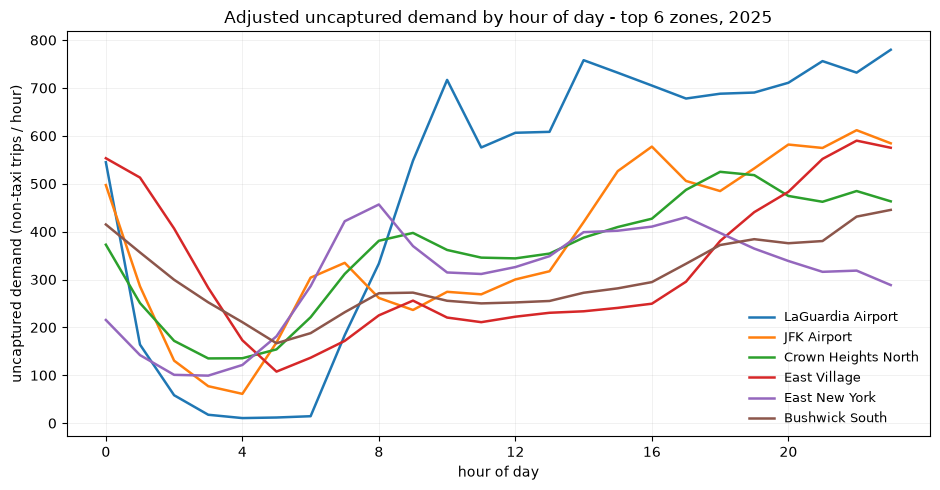

/tmp/ipykernel_406494/1217927314.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[col].astype(str), categories=[str(l) for l in levels])


December zone-ranking agreement, empirical-total vs fitted-total uncaptured demand: Spearman rho = 1.000 over 261 zones


In [19]:
# --- hour-of-day profile for the top-6 uncaptured-demand zones + Dec cross-check ---
top6 = by_zone.head(6)
zone_names = dict(zip(top6["LocationID"], top6["Zone"]))
prof = (pred_rows[pred_rows["LocationID"].isin(top6["LocationID"])]
        .groupby(["LocationID", "hour"])["uncaptured_demand"].mean().unstack("LocationID"))

fig, ax = plt.subplots(figsize=(9.5, 5))
for z in top6["LocationID"]:
    ax.plot(prof.index, prof[z], lw=1.8, label=zone_names[z])
ax.set_xlabel("hour of day")
ax.set_ylabel("uncaptured demand (non-taxi trips / hour)")
ax.set_xticks(range(0, 24, 4))
ax.set_title("Adjusted uncaptured demand by hour of day - top 6 zones, 2025")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()
fig.savefig(f"{PLOTS_DIR}/uncaptured_demand_hourly_profiles_2025.png", dpi=150, bbox_inches="tight")
plt.show()

# cross-check: on held-out December, swap the observed total for the count
# model's fitted mean (the fully model-based, ex-ante version of the same
# statistic) and confirm the zone ranking is stable
from scipy.stats import spearmanr

dec = glm_test[["LocationID", "total_trip_count"]].copy()
dec["p_taxi"] = share_res.predict(
    build_design(glm_test, share_num, share_cats).to_numpy(float))
dec.loc[dec["LocationID"].isin(NO_TAXI_ZONES), "p_taxi"] = 0.0
dec["uncaptured_empirical"] = dec["total_trip_count"] * (1 - dec["p_taxi"])
dec["uncaptured_fitted"] = mus[BEST_VARIANT] * (1 - dec["p_taxi"])
zr = dec.groupby("LocationID")[["uncaptured_empirical", "uncaptured_fitted"]].mean()
rho, _ = spearmanr(zr["uncaptured_empirical"], zr["uncaptured_fitted"])
print(f"December zone-ranking agreement, empirical-total vs fitted-total "
      f"uncaptured demand: Spearman rho = {rho:.3f} over {len(zr)} zones")

## 10. Secondary model: gradient-boosted trees

`HistGradientBoostingRegressor` (sklearn's LightGBM-style GBM; xgboost isn't
in this venv and this needs no extra install) with `loss="poisson"`, so it
optimises the same count likelihood as the GLM and predicts the same
conditional mean $\mathbb{E}[Y_{z,t}]$ — an apples-to-apples nonparametric
benchmark.

Differences from the GLM setup, all deliberate:

- **Raw features, no transforms**: trees are invariant to monotone transforms,
  so count lags enter untransformed; `hour`/`dow`/`month` replace the
  harmonics (trees carve thresholds; sinusoids don't help them).
- **Native NaN handling**: no rows dropped and no imputation needed — missing
  lags/temps are routed by the trees' default-direction rule.
- **Zone via target encoding** (train-period mean of log1p demand per zone)
  instead of 260+ dummies: HistGBR's native categorical support caps at 255
  levels, and the encoding gives trees a *numeric* axis that orders zones by
  base demand, which they can split efficiently. Computed on Jan–Nov only —
  no leakage into December.
- **Trains on all of Jan–Nov** (~2.1M rows) since it's cheap; the GLM used a
  10% sample only for design-matrix memory reasons.

Evaluation is on the **same December test set** as the GLMs, plus a
seasonal-naive baseline (predict the same hour last week,
`total_count_lag168`) to anchor both models against "just repeat last week".

In [20]:
# zone target encoding from TRAIN period only (Dec never touches this)
zone_mean_log = np.log1p(
    train_full.groupby("LocationID")[RESPONSE].mean()
).rename("zone_mean_log")
global_mean_log = float(np.log1p(train_full[RESPONSE].mean()))

GBM_NUM = (COUNT_LAG_COLS  # raw count lags (taxi + total)
           + FEATURES_TRIPCHAR
           + ["temp_c", "precip_mm", "event_count", "hour", "dow", "month",
              "zone_mean_log"])
WEATHER_CODE = {w: i for i, w in enumerate(WEATHER_LEVELS)}
GBM_FEATURES = GBM_NUM + ["weather_code"]


def gbm_frame(df):
    out = df.merge(zone_mean_log, on="LocationID", how="left")
    out["zone_mean_log"] = out["zone_mean_log"].fillna(global_mean_log)
    out["weather_code"] = out["weather_cat"].map(WEATHER_CODE)
    return out[GBM_FEATURES]


X_gbm_train = gbm_frame(train_full)
X_gbm_test = gbm_frame(glm_test)  # common evaluation set

GBM_PATH = f"{MODELS_DIR}/gbm.joblib"
if os.path.exists(GBM_PATH):
    gbm = joblib.load(GBM_PATH)
    print(f"(loaded cached {GBM_PATH})")
else:
    gbm = HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=0.05,
        max_iter=500,
        max_leaf_nodes=63,
        early_stopping=True,      # internal random 10% validation split
        n_iter_no_change=20,
        categorical_features=[GBM_FEATURES.index("weather_code")],
        random_state=SEED,
    )
    gbm.fit(X_gbm_train, train_full[RESPONSE].to_numpy(float))
    joblib.dump(gbm, GBM_PATH)
print(f"boosting rounds used: {gbm.n_iter_}")

mus["gbm"] = gbm.predict(X_gbm_test)
metrics["gbm"] = {**score(y_test, mus["gbm"]),
                  "train_AIC": np.nan, "converged": True,
                  "n_params": np.nan}

# seasonal-naive baseline: same zone, same hour, one week earlier
mus["naive_lag168"] = glm_test["total_count_lag168"].to_numpy(float)
metrics["naive_lag168"] = {**score(y_test, mus["naive_lag168"]),
                           "train_AIC": np.nan, "converged": True,
                           "n_params": 0}

pd.DataFrame(metrics).T.sort_values("test_poisson_dev")

boosting rounds used: 500


,test_MAE,test_RMSE,test_poisson_dev,train_AIC,converged,n_params
gbm,20.266342,41.488913,6.28919,NaN,True,NaN
negbin_event_binary,23.790977,50.631211,9.020996,830652.372321,True,287
event_binary,24.008164,50.934339,9.283702,1099933.316665,True,287
event_cat,24.009703,50.935352,9.283899,1099917.708919,True,289
event_log1p,24.011354,50.937242,9.284426,1099931.694213,True,287
naive_lag168,32.372358,72.261742,18.49837,NaN,True,0


## 11. GLM vs GBM on held-out December

Hourly actual-vs-predicted traces for one high-demand and one mid-demand zone
over the first test week, plus the final metric table above. The traces show
*where* the models differ (peaks, overnight troughs, weekend shape), which the
aggregate metrics can't.

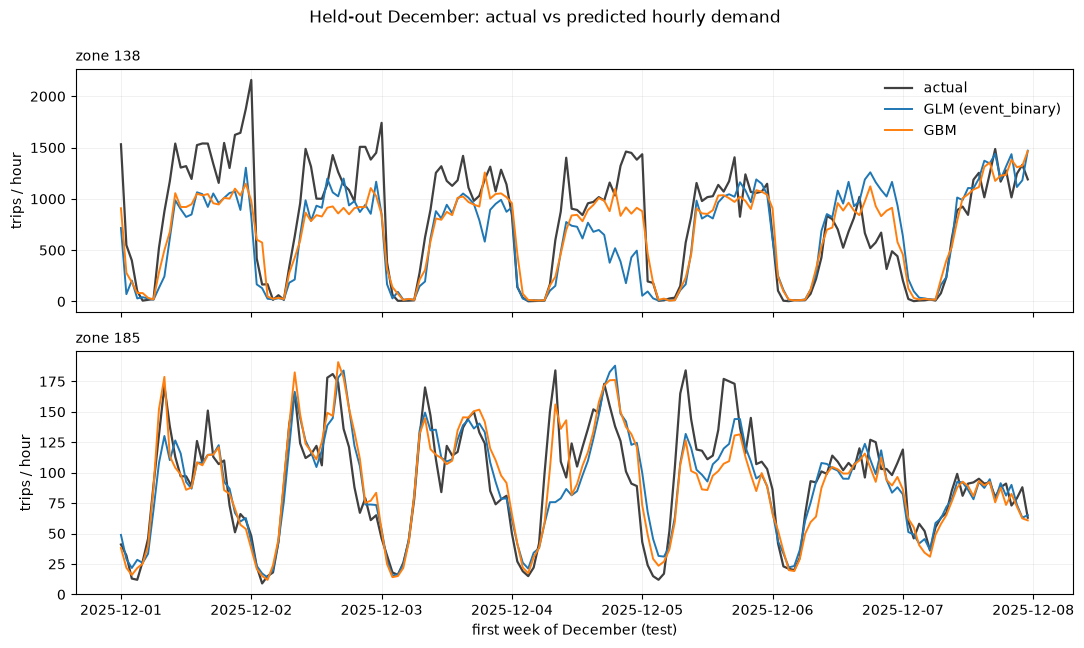

In [21]:
plot_df = glm_test[["pickup_hour", "LocationID", RESPONSE]].copy()
plot_df["mu_glm"] = mus[BEST_VARIANT]
plot_df["mu_gbm"] = mus["gbm"]

zone_totals = plot_df.groupby("LocationID")[RESPONSE].sum().sort_values()
zones_to_plot = [zone_totals.index[-1],                     # busiest zone
                 zone_totals.index[len(zone_totals) // 2]]  # median zone
week_end = plot_df["pickup_hour"].min() + pd.Timedelta(days=7)

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
for ax, z in zip(axes, zones_to_plot):
    zd = (plot_df[(plot_df["LocationID"] == z) & (plot_df["pickup_hour"] < week_end)]
          .sort_values("pickup_hour"))
    ax.plot(zd["pickup_hour"], zd[RESPONSE], color="0.25", lw=1.6, label="actual")
    ax.plot(zd["pickup_hour"], zd["mu_glm"], lw=1.4, label=f"GLM ({BEST_VARIANT})")
    ax.plot(zd["pickup_hour"], zd["mu_gbm"], lw=1.4, label="GBM")
    ax.set_title(f"zone {z}", loc="left", fontsize=10)
    ax.set_ylabel("trips / hour")
    ax.grid(alpha=0.25, lw=0.5)
axes[0].legend(loc="upper right", frameon=False)
axes[1].set_xlabel("first week of December (test)")
fig.suptitle("Held-out December: actual vs predicted hourly demand", y=0.99)
plt.tight_layout()
fig.savefig(f"{PLOTS_DIR}/demand_model_test_week.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# --- Performance by borough: citywide MAE/RMSE hides where the model is
# actually usable. Taxi (yellow+green) has near-zero presence outside
# Manhattan citywide (mean capture: Manhattan 25.0%, Queens 3.1%, Brooklyn
# 1.7%, Bronx 0.6%, Staten Island ~0% -- see uncaptured_demand_by_zone_2025.csv),
# so a "help yellow cabs win back share" recommendation is only actionable
# where there's a real baseline presence to build from. This checks whether
# the model is actually GOOD there, not just citywide-good.
zone_borough = zone_lookup.set_index("LocationID")["Borough"]
test_borough = glm_test["LocationID"].map(zone_borough)

by_borough = []
for name in [f"negbin_{BEST_VARIANT}", "gbm", "naive_lag168"]:
    mu = mus[name]
    for b in ["Manhattan", "Queens", "Brooklyn", "Bronx", "Staten Island"]:
        mask = (test_borough == b).to_numpy()
        if mask.sum() == 0:
            continue
        by_borough.append({"model": name, "borough": b, "n": int(mask.sum()),
                            **score(y_test[mask], mu[mask])})
    by_borough.append({"model": name, "borough": "Citywide", "n": len(y_test),
                        **score(y_test, mu)})

borough_tbl = pd.DataFrame(by_borough).set_index(["model", "borough"]).round(2)
borough_tbl


n  test_MAE  test_RMSE  \
model               borough                                      
negbin_event_binary Manhattan       49848     42.14      73.64   
                    Queens          51336     17.84      47.83   
                    Brooklyn        45384     23.73      44.99   
                    Bronx           31992     14.08      23.29   
                    Staten Island   14880      5.10       7.75   
                    Citywide       194184     23.79      50.63   
gbm                 Manhattan       49848     33.72      59.26   
                    Queens          51336     15.90      39.02   
                    Brooklyn        45384     20.99      38.45   
                    Bronx           31992     12.89      20.20   
                    Staten Island   14880      4.91       7.52   
                    Citywide       194184     20.27      41.49   
naive_lag168        Manhattan       49848     60.82     110.14   
                    Queens          51336     22.88      63.10   
                    Brooklyn        45384     31.51      61.58   
                    Bronx           31992     17.39      31.27   
                    Staten Island   14880      6.27      10.01   
                    Citywide       194184     32.37      72.26   

                                   test_poisson_dev  
model               borough                          
negbin_event_binary Manhattan                 16.37  
                    Queens                     7.09  
                    Brooklyn                   8.59  
                    Bronx                      4.71  
                    Staten Island              2.08  
                    Citywide                   9.02  
gbm                 Manhattan                 10.21  
                    Queens                     5.43  
                    Brooklyn                   6.40  
                    Bronx                      3.58  
                    Staten Island              1.93  
                    Citywide                   6.29  
naive_lag168        Manhattan                 36.73  
                    Queens                    13.41  
                    Brooklyn                  16.06  
                    Bronx                      8.55  
                    Staten Island              4.65  
                    Citywide                  18.50

## 12. Takeaways

- **Model selection**: the best GLM variant (chosen on held-out December
  Poisson deviance, table in §10) and the NB refit share point predictions;
  the NB + zone-clustered SEs is the specification to report *inference*
  from, and the metric table shows which model to report *forecasts* from.
- **Both models must beat `naive_lag168`** to justify their existence; the
  margin over the naive baseline is the honest headline number.
- The GBM sees ~10× more training data and can carve interactions
  (hour × zone × lag) the GLM's additive log-linear form can't, so a GBM edge
  on MAE/RMSE is expected; the GLM keeps interpretable IRRs (§8) and honest
  uncertainty, which the GBM has neither of. That trade-off — not a single
  metric — is the comparison to write up.
- **The dispatch deliverable** comes from the thinning decomposition (§9):
  the share model's zone effects say which zones are structurally underserved
  *after* adjusting for time/weather/events (with honest clustered CIs), and
  $\hat\lambda(1-\hat p)$ — exported per zone to
  `data/processed/uncaptured_demand_by_zone_2025.csv` — is the trips/hour rate
  to stage capacity against.
- **Citywide error hides where the model actually matters**: taxi's mean
  capture share is 25.0% in Manhattan vs. 3.1% / 1.7% / 0.6% / ~0% in
  Queens / Brooklyn / Bronx / Staten Island (borough table above) — most of
  the map is a market taxi has already lost almost entirely, so a "help
  yellow cabs" recommendation only makes sense scoped to zones with a real
  baseline presence (Manhattan, plus the two airports as dedicated taxi
  infrastructure). The borough breakdown above, not the citywide average, is
  the honest "would this actually help the TLC" check.
- **Preprocessing**: trip validity is now a hard row-level filter (duration,
  distance, fare floor, non-negative charges, VendorID/RatecodeID/
  payment_type/passenger_count, real-zone-only pickup+dropoff) applied
  upstream in `scripts/tlc_trips.py` — an invalid trip is dropped before this
  table is ever built, not nulled and kept as before.
